In [ ]:
from pathlib import Path

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

SYNTHETIC_DATA_DIR = REPO_ROOT / 'data' / 'synthetic'
RAW_DATA_DIR = REPO_ROOT / 'data' / 'raw'


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(RAW_DATA_DIR / 'imu_drop_v3.csv')
print(f"Total samples: {len(df)}")

Total samples: 105


In [3]:
# Constant definition: gravity = +9.81 m/s² along +z axis

G = 9.81
G_WORLD_NED = +G

FREEFALL_THRESHOLD = 0.30 * G   # m/s²
IMPACT_THRESHOLD   = 2.00 * G
CALIB_SAMPLES      = 30

In [4]:
# Load + units + dt + calibrate + detect events
t_us  = df['t_us'].values.astype(float)
t_s   = (t_us - t_us[0]) * 1e-6
dt_arr = np.diff(t_s, prepend=t_s[0] - np.mean(np.diff(t_s)))

a_body = df[['aX','aY','aZ']].values.astype(float) * G        # g → m/s²

# Calibration
calib_mean = np.mean(a_body[:CALIB_SAMPLES], axis=0)
bias_a = calib_mean - np.array([0.0, 0.0, +G])
a_body_c = a_body - bias_a

# 1D body -> world
a_specific_world_z = -a_body_c[:, 2]                  # m/s², specific force, world Z
a_input            = a_specific_world_z + G_WORLD_NED # inertial accel along world Z
a_mag              = np.linalg.norm(a_body_c, axis=1)

def detect_release(mag, threshold, window=3):
    below = mag < threshold
    for i in range(len(below) - window):
        if np.all(below[i:i+window]):
            return i
    return None

def detect_impact(mag, threshold, start):
    for i in range(start, len(mag)):
        if mag[i] > threshold:
            return i
    return len(mag) - 1

release_idx = detect_release(a_mag, FREEFALL_THRESHOLD)
impact_idx  = detect_impact(a_mag, IMPACT_THRESHOLD, release_idx)
fall_time   = t_s[impact_idx] - t_s[release_idx]
print(f"Release at t={t_s[release_idx]:.3f}s, impact at t={t_s[impact_idx]:.3f}s")
print(f"Fall: {fall_time:.3f}s → height ≈ {0.5*G*fall_time**2:.2f} m")

Release at t=0.871s, impact at t=1.312s
Fall: 0.441s → height ≈ 0.95 m


In [5]:
# Ground truth
n_total = len(t_s)
z_true  = np.zeros(n_total)
vz_true = np.zeros(n_total)
az_true = np.zeros(n_total)

t_release = t_s[release_idx]
t_impact  = t_s[impact_idx]
z_at_impact = 0.5 * G * (t_impact - t_release)**2

for k in range(n_total):
    if release_idx <= k <= impact_idx:
        tau = t_s[k] - t_release
        z_true[k]  = 0.5 * G * tau**2
        vz_true[k] = G * tau
        az_true[k] = G
    elif k > impact_idx:
        z_true[k] = z_at_impact   # idealized stop

In [6]:
# Kalman Filter
# State: x = [vz, az]

def F_fn(dt_):
    return np.array([[1.0, dt_],
                     [0.0, 1.0]])

H = np.array([[0.0, 1.0]])

# Process noise
Q = np.diag([1e-4, 1.0])
# Measurement noise
R = np.array([[0.5**2]])

x = np.zeros(2)               # start at rest
P = np.diag([0.01, 0.01])

est       = np.zeros((n_total, 2))   # [vz, az]
P_diag    = np.zeros((n_total, 2))   # save diagonal for diagnostics
innov     = np.zeros(n_total)
K_history = np.zeros((n_total, 2))

for k in range(n_total):
    dt_k = dt_arr[k] if k > 0 else np.mean(dt_arr[1:])
    F = F_fn(dt_k)

    # Predict
    x = F @ x
    P = F @ P @ F.T + Q

    z_meas = np.array([a_input[k]])
    y      = z_meas - H @ x                  # innovation
    S      = H @ P @ H.T + R                 # innovation covariance
    K      = P @ H.T @ np.linalg.inv(S)      # Kalman gain
    x      = x + (K @ y).flatten()           # corrected state
    P      = (np.eye(2) - K @ H) @ P         # corrected covariance

    est[k]       = x
    P_diag[k]    = np.diag(P)
    innov[k]     = y[0]
    K_history[k] = K.flatten()

# Position by integrating filtered velocity
z_est = np.zeros(n_total)
for k in range(1, n_total):
    z_est[k] = z_est[k-1] + est[k, 0] * dt_arr[k]

print(f"Final z:  est={z_est[-1]:.3f} m   GT={z_true[-1]:.3f} m")
print(f"Final vz: est={est[-1,0]:.3f} m/s GT={vz_true[-1]:.3f} m/s")
print(f"Final az: est={est[-1,1]:.3f} m/s² GT={az_true[-1]:.3f} m/s²")

Final z:  est=3.363 m   GT=0.954 m
Final vz: est=9.452 m/s GT=0.000 m/s
Final az: est=9.431 m/s² GT=0.000 m/s²


In [7]:
# RMSE on free-fall window
ff = slice(release_idx, impact_idx + 1)
rmse_z  = np.sqrt(np.mean((z_est[ff]   - z_true[ff])**2))
rmse_vz = np.sqrt(np.mean((est[ff, 0]  - vz_true[ff])**2))

# Acceleration comparison
rmse_az_raw      = np.sqrt(np.mean((a_input[ff] - az_true[ff])**2))
rmse_az_filtered = np.sqrt(np.mean((est[ff, 1]  - az_true[ff])**2))

print(f"Free-fall RMSE — z (filtered):  {rmse_z:.3f} m")
print(f"Free-fall RMSE — vz (filtered): {rmse_vz:.3f} m/s")
print(f"Free-fall RMSE — az (raw):      {rmse_az_raw:.3f} m/s²")
print(f"Free-fall RMSE — az (filtered): {rmse_az_filtered:.3f} m/s²")
print(f"\nFilter improvement on az RMSE:  {rmse_az_raw - rmse_az_filtered:.3f} m/s²")


Free-fall RMSE — z (filtered):  0.356 m
Free-fall RMSE — vz (filtered): 1.156 m/s
Free-fall RMSE — az (raw):      3.703 m/s²
Free-fall RMSE — az (filtered): 3.146 m/s²

Filter improvement on az RMSE:  0.557 m/s²


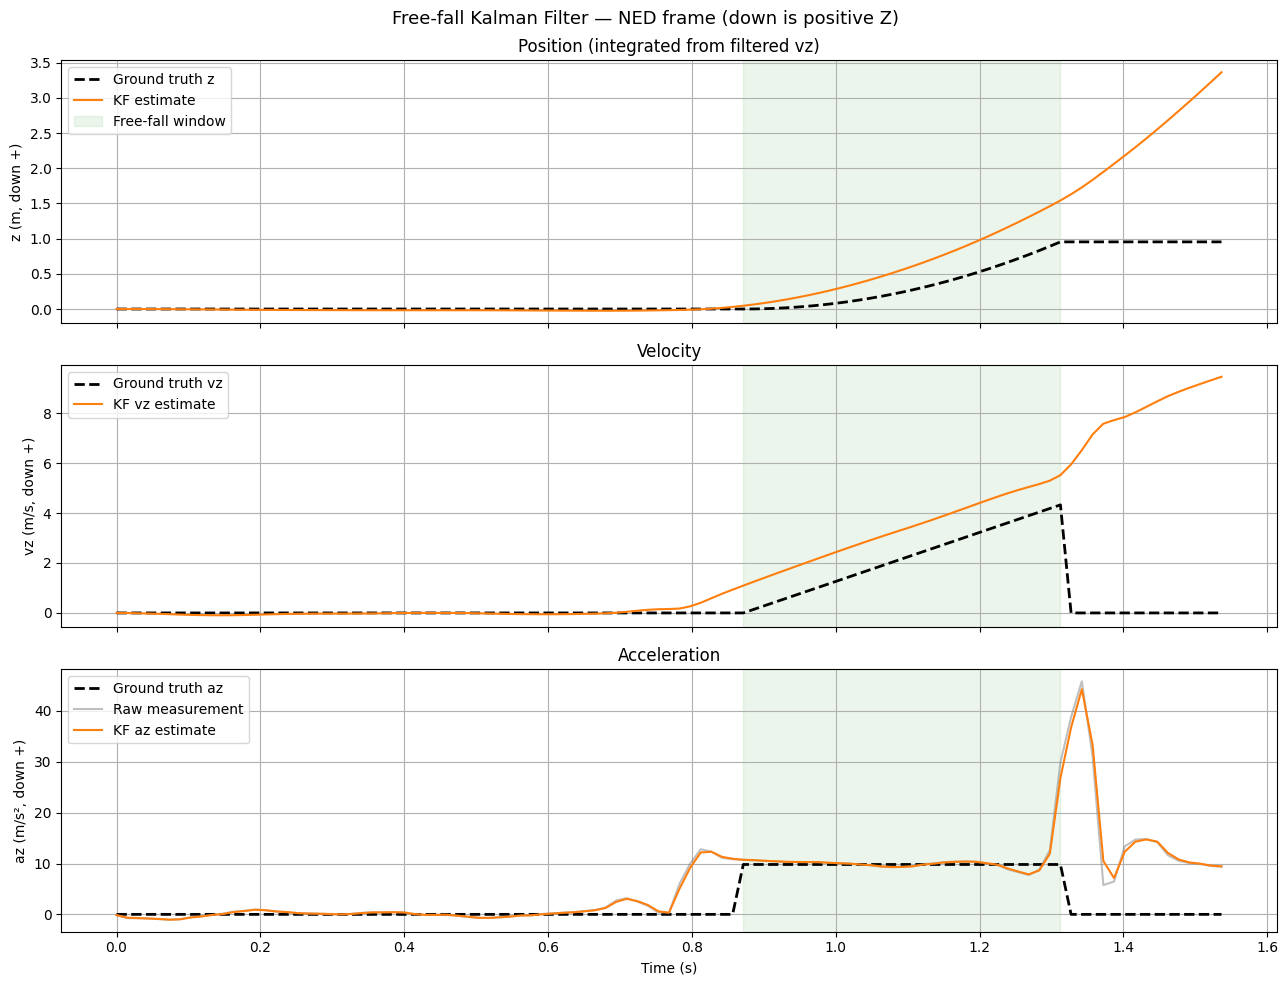

In [8]:
# Plots (with free fall window highligted)
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle('Free-fall Kalman Filter — NED frame (down is positive Z)', fontsize=13)

axes[0].plot(t_s, z_true, '--', color='black', label='Ground truth z', linewidth=2)
axes[0].plot(t_s, z_est,  label='KF estimate', color='tab:orange')
axes[0].axvspan(t_s[release_idx], t_s[impact_idx], color='green', alpha=0.08, label='Free-fall window')
axes[0].set_ylabel('z (m, down +)'); axes[0].set_title('Position (integrated from filtered vz)')
axes[0].legend(loc='upper left'); axes[0].grid(True)

axes[1].plot(t_s, vz_true, '--', color='black', label='Ground truth vz', linewidth=2)
axes[1].plot(t_s, est[:, 0], label='KF vz estimate', color='tab:orange')
axes[1].axvspan(t_s[release_idx], t_s[impact_idx], color='green', alpha=0.08)
axes[1].set_ylabel('vz (m/s, down +)'); axes[1].set_title('Velocity')
axes[1].legend(loc='upper left'); axes[1].grid(True)

axes[2].plot(t_s, az_true, '--', color='black', label='Ground truth az', linewidth=2)
axes[2].plot(t_s, a_input, label='Raw measurement', color='gray', alpha=0.5)
axes[2].plot(t_s, est[:, 1], label='KF az estimate', color='tab:orange')
axes[2].axvspan(t_s[release_idx], t_s[impact_idx], color='green', alpha=0.08)
axes[2].set_ylabel('az (m/s², down +)'); axes[2].set_xlabel('Time (s)')
axes[2].set_title('Acceleration')
axes[2].legend(loc='upper left'); axes[2].grid(True)

plt.tight_layout(); plt.show()